In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [2]:
df = pd.read_csv('height-weight.csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

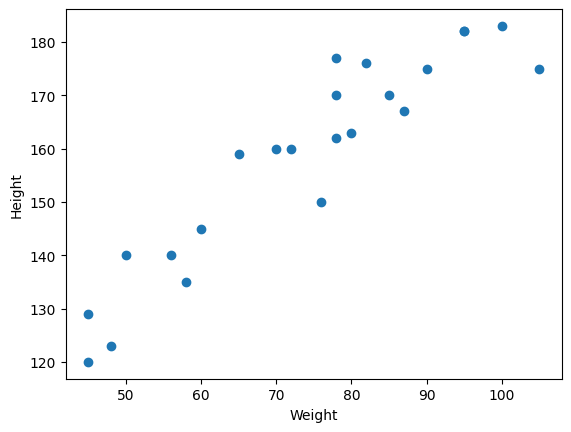

In [3]:
##scatter plot
plt.scatter(df['Weight'],df['Height'])
plt.xlabel("Weight")
plt.ylabel("Height")

In [4]:

## Correlation- It measures how strongly different columns in our dataset are related to each other. 1 means perfect positive correlation, -1 means perfect negative correlation, and 0 means no correlation at all.
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


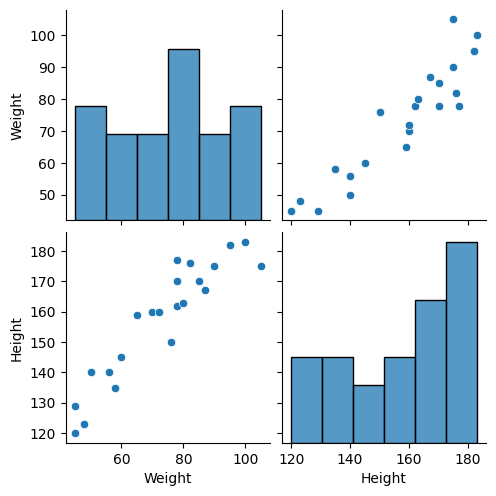

In [5]:

## Seaborn for visualization
import seaborn as sns
sns.pairplot(df)

In [6]:
## Independent and dependent features
X=df[['Weight']] ### independent features should be data frame or 2 dimesnionalarray
y=df['Height'] ## this variiable can be in series or 1d array

In [9]:
X.shape
y.shape

(23,)

In [10]:

## Train Test Split
from sklearn.model_selection import train_test_split

In [11]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

In [12]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((18, 1), (5, 1), (18,), (5,))

In [13]:

## Standardization
from sklearn.preprocessing import StandardScaler

In [15]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train) # fit = mean and standard deviation of X_train and tranform = apply the formula for the z score

In [16]:
X_train
# y_train

array([[ 1.73689094],
       [-0.92026952],
       [ 1.4542143 ],
       [ 0.21043706],
       [-1.48562281],
       [ 1.17153765],
       [-1.6552288 ],
       [-0.80719886],
       [-0.24184557],
       [ 0.0973664 ],
       [-1.37255215],
       [-1.03334018],
       [-0.12877492],
       [ 0.88886101],
       [ 0.43657837],
       [ 0.60618436],
       [ 0.71925502],
       [ 0.32350772]])

In [17]:
# the reason we do this is because of the (dataleakage)
X_test=scaler.transform(X_test) # apply the formula for the z score by using the mean and standard deviation of X_train

In [18]:

X_test

array([[ 0.21043706],
       [ 0.21043706],
       [-1.6552288 ],
       [ 1.17153765],
       [-0.52452222]])

In [19]:
## Apply Simple Linear Regression
from sklearn.linear_model import LinearRegression

The number of jobs to use for the computation. This will only provide speedup in case of sufficiently large problems, that is if firstly n_targets > 1 and secondly X is sparse or if positive is set to True. None means 1 unless in a joblib.parallel_backend context. -1 means using all processors. 

In [20]:
regression=LinearRegression()


In [21]:
regression.fit(X_train,y_train) # X_train is 2d array and y_train is 1d array

LinearRegression()

In [22]:
print("Coefficient or slope of weight:",regression.coef_)
print("Intercept:",regression.intercept_)

Coefficient or slope of weight: [17.03440872]
Intercept: 157.5


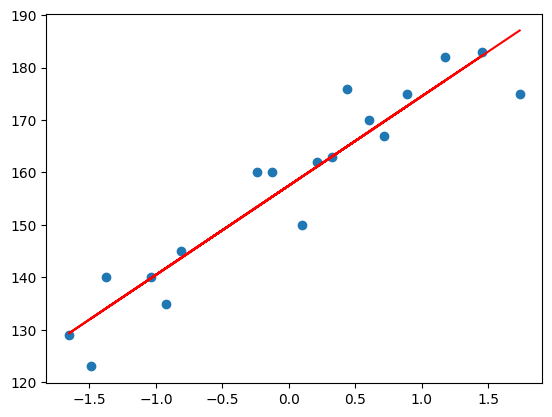

In [23]:
## plot Training data plot best fit line
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train),'r')


prediction of train data
predicted height output= intercept +coef_(Weights)
y_pred_test =157.5 + 17.03(X_train)

Prediction of test data
predicted height output = intercept + coef_(Weights)
y_pred_test = 157.5 + 17.03(X_test)

In [24]:

## Prediction for test data
y_pred=regression.predict(X_test)

In [25]:
y_pred, y_test

(array([161.08467086, 161.08467086, 129.3041561 , 177.45645118,
        148.56507414]),
 15    177
 9     170
 0     120
 8     182
 17    159
 Name: Height, dtype: int64)

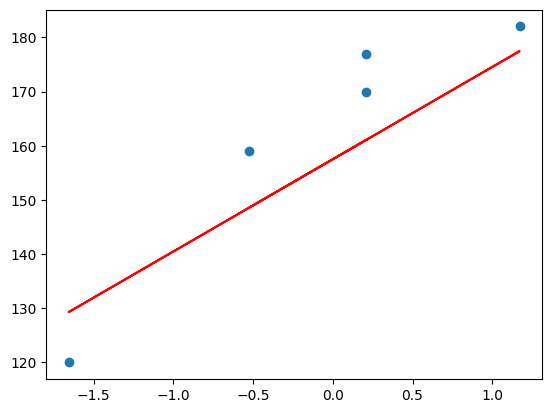

In [26]:
plt.scatter(X_test,y_test)
plt.plot(X_test,regression.predict(X_test),'r')

In [27]:

## Performance Metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [28]:
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred) # y_test is actual value and y_pred is predicted value
rmse=np.sqrt(mse)
print(mae,'Mean Absolute Error')
print(mse,'Mean squared Error')
print(rmse,'Root Mean Squared Error')


9.822657814519232 Mean Absolute Error
109.77592599051664 Mean squared Error
10.477400726827081 Root Mean Squared Error



R square
Formula

R^2 = 1 - SSR/SST

R^2 = coefficient of determination SSR = sum of squares of residuals SST = total sum of squares

In [29]:

from sklearn.metrics import r2_score

In [30]:
score=r2_score(y_test,y_pred)
print(score)

0.776986986042344



Adjusted R2 = 1 – [(1-R2)*(n-1)/(n-k-1)]

where:

R2: The R2 of the model n: The number of observations k: The number of predictor variables

In [31]:

#display adjusted R-squared
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.7026493147231252

In [32]:
## Prediction For new data
print('the height of the person with weight 90 is:',regression.predict(scaler.transform([[90]])))

the height of the person with weight 90 is: [172.64122168]


d:\AI-ML-learning\Multi Regression\myenv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


<div class="alert alert-block alert-info">
<b>Assumptions:</b> 
<li>Plot the scatter plot for the preditcion - if it is linear distributed than we can consider that the model is performing well.</li>
<li>Residuals - difference between y_test - y_pred,
if we plot the residual using histplot ,if we are getting the normal distribution(gaussain distrubution where left and right are equally distributed if we consider the mean of the graph.) then we can consider that the model is performing well. </li>
<li>Scatter plot with respect to prediction and residual
   (Uniform distribution - data points will be availabel in both positive and negative points)</li>
</div>
